In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('/content/diminos_data.csv')

In [54]:
data.head()

,order_id,order_placed_at,order_delivered_at
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056


In [55]:
data.shape

(15000, 3)

In [56]:
data.isnull().sum()

,0
order_id,0
order_placed_at,0
order_delivered_at,0


In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            15000 non-null  int64 
 1   order_placed_at     15000 non-null  object
 2   order_delivered_at  15000 non-null  object
dtypes: int64(1), object(2)
memory usage: 351.7+ KB


In [58]:
data.dtypes

,0
order_id,int64
order_placed_at,object
order_delivered_at,object


In [59]:
data = data.drop('order_id',axis = 1)

In [60]:
from datetime import datetime

data.order_placed_at = data.order_placed_at.apply(datetime.fromisoformat)
data.order_delivered_at = data.order_delivered_at.apply(datetime.fromisoformat)
data.shape

(15000, 2)

In [61]:
data.head()

,order_placed_at,order_delivered_at
0,2023-03-01 00:00:59,2023-03-01 00:18:07.443132
1,2023-03-01 00:03:59,2023-03-01 00:19:34.925241
2,2023-03-01 00:07:22,2023-03-01 00:22:28.291385
3,2023-03-01 00:07:47,2023-03-01 00:46:19.019399
4,2023-03-01 00:09:03,2023-03-01 00:25:13.619056


In [62]:
data["time_taken_hrs"] = data.order_delivered_at - data.order_placed_at
data.time_taken_hrs = data.time_taken_hrs.apply(lambda x: x.total_seconds() / 60 / 60)

In [63]:
data.head()

,order_placed_at,order_delivered_at,time_taken_hrs
0,2023-03-01 00:00:59,2023-03-01 00:18:07.443132,0.285679
1,2023-03-01 00:03:59,2023-03-01 00:19:34.925241,0.259979
2,2023-03-01 00:07:22,2023-03-01 00:22:28.291385,0.251748
3,2023-03-01 00:07:47,2023-03-01 00:46:19.019399,0.642228
4,2023-03-01 00:09:03,2023-03-01 00:25:13.619056,0.269616


In [64]:
data.describe()

,order_placed_at,order_delivered_at,time_taken_hrs
count,15000,15000,15000.000000
mean,2023-03-14 10:49:21.257533184,2023-03-14 11:09:51.220893184,0.341656
min,2023-03-01 00:00:59,2023-03-01 00:18:07.443132,0.250000
25%,2023-03-07 15:57:25,2023-03-07 16:20:38.480371200,0.254580
50%,2023-03-14 09:32:06.500000,2023-03-14 09:55:10.638778880,0.263300
75%,2023-03-21 07:07:15.500000,2023-03-21 07:25:22.135336704,0.287994
max,2023-03-27 23:58:20,2023-03-29 02:42:50.645252,121.663856
std,NaN,NaN,1.602673


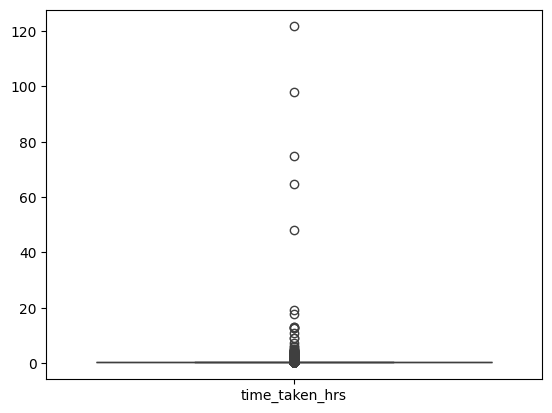

In [65]:
sns.boxplot(data)
plt.show()


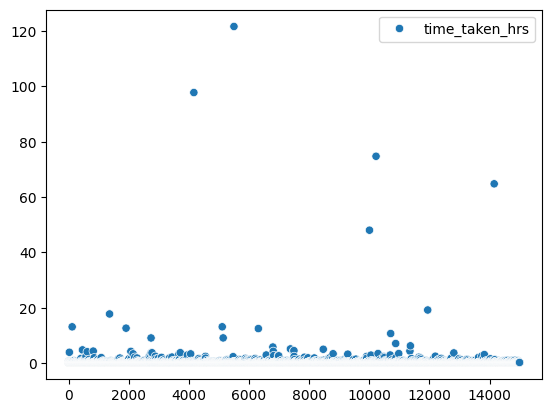

In [66]:
sns.scatterplot(data)
plt.show()


In [67]:
data1 = data.drop("order_delivered_at", axis=1)
grouped = data1.groupby(pd.Grouper(key="order_placed_at", freq="2H"))
grouped = pd.DataFrame(grouped.size().reset_index(name='time_taken_hrs'))

/tmp/ipython-input-1870238134.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grouped = data1.groupby(pd.Grouper(key="order_placed_at", freq="2H"))


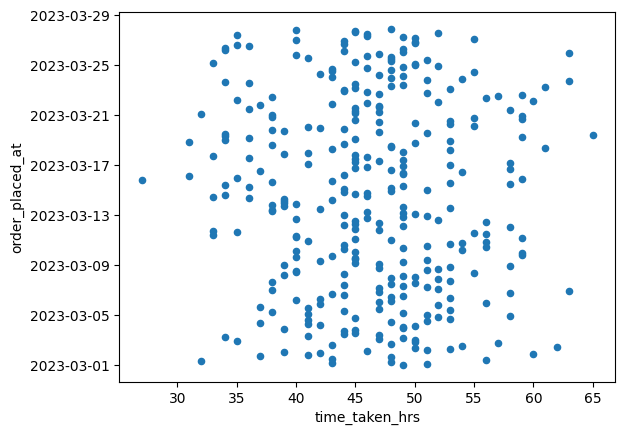

In [68]:
grouped.plot(x="time_taken_hrs", y="order_placed_at", kind="scatter")
plt.show()


In [69]:
grouped[grouped["time_taken_hrs"] < 24].shape

(0, 2)